<a href="https://colab.research.google.com/github/melissa-04/hgsoc-spatial-parpi-tme/blob/main/notebooks/04_spatial_structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import anndata as ad
import matplotlib.pyplot as plt
import importlib.metadata as im

BASE = '/content/drive/MyDrive/ovarian-spatial'
PROC = f'{BASE}/data/processed'
META = f'{BASE}/metadata'
FIG  = f'{BASE}/results/figures'
os.makedirs(FIG, exist_ok=True)

sc.settings.verbosity = 1
for p in ['numpy','pandas','scipy','anndata','scanpy','squidpy']:
    print(f'{p:<10}{im.version(p)}')

adata = ad.read_h5ad(f'{PROC}/GSE288483_clustered.h5ad')
prop  = pd.read_csv(f'{PROC}/spatial_celltype_composition.csv', index_col=0)

TYPES = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','Mesothelial',
         'Plasma','T','Endothelial','B','DC','NK_ILC','Mast']

bar = '=' * 88
print('\n' + bar); print('ALIGNMENT'); print(bar)
print(f'adata spots : {adata.n_obs:,}')
print(f'prop  rows  : {len(prop):,}')
print(f'index match : {adata.obs_names.equals(prop.index)}')

prop = prop.reindex(adata.obs_names)
assert prop[TYPES].notna().all().all(), 'missing proportions after reindex'

adata.obsm['proportions'] = prop[TYPES].to_numpy()
adata.uns['prop_names']   = TYPES
for t in TYPES:
    adata.obs[t] = prop[t].to_numpy()
adata.obs['CAF_total']    = prop[['CAF_1','CAF_2','CAF_3']].sum(axis=1).to_numpy()
adata.obs['Immune_total'] = prop[['Macrophages','T','B','Plasma','DC',
                                  'NK_ILC','Mast']].sum(axis=1).to_numpy()

print(f'\nobsm["proportions"] : {adata.obsm["proportions"].shape}')
print(f'row sums == 1       : {np.allclose(adata.obsm["proportions"].sum(1), 1.0)}')

print('\n' + bar); print('PER-SAMPLE SCALE'); print(bar)
print(f"{'ID':<5}{'slide':<7}{'group':<11}{'spots':>7}{'um/px':>9}{'gap_px':>9}")
print('-' * 88)
for sid in ['S1','S2','S3','S4','R1','R2','R3','R4']:
    sf = adata.uns['spatial'][sid]['scalefactors']
    m  = adata.obs.paper_id == sid
    print(f'{sid:<5}{adata.obs.slide[m].iloc[0]:<7}{adata.obs.group[m].iloc[0]:<11}'
          f'{int(m.sum()):>7}{sf["um_per_px_measured"]:>9.4f}'
          f'{sf["spot_gap_px_measured"]:>9.2f}')

print('\n' + bar); print('COORDINATE RANGES  (why we build graphs per sample)'); print(bar)
print(f"{'ID':<5}{'x_min':>8}{'x_max':>8}{'y_min':>8}{'y_max':>8}{'width_um':>10}")
print('-' * 88)
for sid in ['S1','S2','S3','S4','R1','R2','R3','R4']:
    m   = (adata.obs.paper_id == sid).to_numpy()
    xy  = adata.obsm['spatial'][m]
    upp = adata.uns['spatial'][sid]['scalefactors']['um_per_px_measured']
    print(f'{sid:<5}{xy[:,0].min():>8.0f}{xy[:,0].max():>8.0f}'
          f'{xy[:,1].min():>8.0f}{xy[:,1].max():>8.0f}'
          f'{(xy[:,0].max()-xy[:,0].min())*upp:>10.0f}')

print('\n' + bar); print('COMPOSITION SUMMARY'); print(bar)
print(f"{'ID':<5}{'grp':<4}{'Malig':>8}{'CAF':>8}{'Immune':>8}{'Macro':>8}{'T':>7}")
print('-' * 88)
for sid in ['S1','S2','S3','S4','R1','R2','R3','R4']:
    m = adata.obs.paper_id == sid
    print(f'{sid:<5}{adata.obs.group[m].iloc[0][:1]:<4}'
          f'{adata.obs.Malignant[m].mean():>8.3f}{adata.obs.CAF_total[m].mean():>8.3f}'
          f'{adata.obs.Immune_total[m].mean():>8.3f}'
          f'{adata.obs.Macrophages[m].mean():>8.3f}{adata.obs["T"][m].mean():>7.3f}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_with_props.h5ad', compression='gzip')
print(f'\n[saved] {PROC}/GSE288483_with_props.h5ad')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
numpy     2.5.2
pandas    3.0.5
scipy     1.16.3
anndata   0.13.2
scanpy    1.12.3
squidpy   1.8.3

ALIGNMENT
adata spots : 15,312
prop  rows  : 15,312
index match : True

obsm["proportions"] : (15312, 13)
row sums == 1       : True

PER-SAMPLE SCALE
ID   slide  group        spots    um/px   gap_px
----------------------------------------------------------------------------------------
S1   B      sensitive     2116   0.7633   131.00
S2   A      sensitive     1131   0.7576   132.00
S3   A      sensitive     2002   0.7576   132.00
S4   A      sensitive     1392   0.7576   132.00
R1   B      resistant     2026   0.7633   131.00
R2   B      resistant     3278   0.7633   131.00
R3   B      resistant     1833   0.7633   131.00
R4   A      resistant     1534   0.7576   132.00

COORDINATE RANGES  (why we build graphs per sample)
ID      x_min   x_max   y_min   y_max

In [2]:

import scipy.sparse as sp
from scipy.spatial import cKDTree

RADIUS_UM = 120.0        # slightly above 100 to be safe against rounding
ORDER = ['S1','S2','S3','S4','R1','R2','R3','R4']

bar = '=' * 88
print(bar); print(f'NEIGHBOUR GRAPH  (radius {RADIUS_UM:.0f} um, built per sample)'); print(bar)
print(f"{'ID':<5}{'spots':>7}{'radius_px':>11}{'edges':>9}{'mean_nb':>9}"
      f"{'min':>5}{'max':>5}{'isolated':>10}")
print('-' * 88)

rows, cols = [], []
idx_all = np.arange(adata.n_obs)
nb_counts = np.zeros(adata.n_obs, dtype=int)

for sid in ORDER:
    m   = (adata.obs.paper_id == sid).to_numpy()
    gi  = idx_all[m]                                   # global indices
    xy  = adata.obsm['spatial'][m].astype(float)
    upp = adata.uns['spatial'][sid]['scalefactors']['um_per_px_measured']
    r_px = RADIUS_UM / upp

    tree  = cKDTree(xy)
    pairs = tree.query_pairs(r=r_px, output_type='ndarray')

    rows.extend(gi[pairs[:, 0]]); cols.extend(gi[pairs[:, 1]])
    rows.extend(gi[pairs[:, 1]]); cols.extend(gi[pairs[:, 0]])

    deg = np.bincount(pairs.ravel(), minlength=len(gi))
    nb_counts[gi] = deg
    print(f'{sid:<5}{len(gi):>7}{r_px:>11.1f}{len(pairs):>9,}{deg.mean():>9.2f}'
          f'{deg.min():>5}{deg.max():>5}{int((deg == 0).sum()):>10}')

W = sp.csr_matrix((np.ones(len(rows)), (rows, cols)),
                  shape=(adata.n_obs, adata.n_obs))
W.data[:] = 1.0
adata.obsp['spatial_connectivities'] = W
adata.obs['n_neighbours'] = nb_counts
adata.uns['spatial_neighbors'] = {'radius_um': RADIUS_UM,
                                  'coord_type': 'generic',
                                  'connectivities_key': 'spatial_connectivities'}

print('-' * 88)
print(f'total edges (directed) : {W.nnz:,}')
print(f'mean neighbours        : {nb_counts.mean():.2f}   (hex grid max = 6)')
print(f'isolated spots         : {int((nb_counts == 0).sum())}')

print('\n' + bar); print('CROSS-SAMPLE LEAKAGE CHECK'); print(bar)
samp = adata.obs.paper_id.to_numpy()
src, dst = W.nonzero()
leak = (samp[src] != samp[dst]).sum()
print(f'edges connecting different samples : {leak}   (must be 0)')

print('\n' + bar); print('DEGREE DISTRIBUTION'); print(bar)
print(f"{'neighbours':<12}{'spots':>8}{'%':>8}   interpretation")
print('-' * 88)
INTERP = {0:'isolated', 1:'tip', 2:'edge', 3:'edge', 4:'edge',
          5:'near-interior', 6:'full interior'}
for k in range(0, 8):
    n = int((nb_counts == k).sum())
    if n:
        print(f'{k:<12}{n:>8,}{100*n/adata.n_obs:>7.1f}%   {INTERP.get(k,"?")}')

adata.obs['is_border'] = (nb_counts < 6)
print(f'\nborder spots (<6 neighbours) : {int(adata.obs.is_border.sum()):,}'
      f'  ({100*adata.obs.is_border.mean():.1f}%)')
print('by sample:')
for sid in ORDER:
    m = adata.obs.paper_id == sid
    print(f'   {sid}: {100*adata.obs.is_border[m].mean():>5.1f}%')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_with_props.h5ad', compression='gzip')
print(f'\n[saved] graph in obsp["spatial_connectivities"]')

NEIGHBOUR GRAPH  (radius 120 um, built per sample)
ID     spots  radius_px    edges  mean_nb  min  max  isolated
----------------------------------------------------------------------------------------
S1      2116      157.2    6,122     5.79    2    6         0
S2      1131      158.4    3,226     5.70    2    6         0
S3      2002      158.4    5,788     5.78    1    6         0
S4      1392      158.4    3,907     5.61    1    6         0
R1      2026      157.2    5,714     5.64    1    6         0
R2      3278      157.2    9,050     5.52    1    6         0
R3      1833      157.2    5,252     5.73    2    6         0
R4      1534      158.4    4,337     5.65    2    6         0
----------------------------------------------------------------------------------------
total edges (directed) : 86,792
mean neighbours        : 5.67   (hex grid max = 6)
isolated spots         : 0

CROSS-SAMPLE LEAKAGE CHECK
edges connecting different samples : 0   (must be 0)

DEGREE DISTRIBUTION
n

MORAN'S I PER SAMPLE   (1 = fully clustered, 0 = random)
feature             S1      S2      S3      S4      R1      R2      R3      R4    mean
--------------------------------------------------------------------------------------------
Malignant        0.640   0.577   0.622   0.559   0.618   0.879   0.596   0.644   0.642
CAF_1            0.637   0.596   0.358   0.387   0.609   0.520   0.377   0.327   0.476
CAF_2            0.741   0.539   0.707   0.608   0.645   0.905   0.279   0.739   0.645
CAF_3            0.793   0.746   0.482   0.554   0.716   0.774   0.615   0.857   0.692
Macrophages      0.473   0.618   0.665   0.307   0.350   0.607   0.602   0.425   0.506
Mesothelial      0.480   0.336   0.773   0.499   0.459   0.335   0.814   0.461   0.520
Plasma           0.726   0.647   0.175   0.337   0.208   0.574   0.721   0.371   0.470
T                0.534   0.310   0.243   0.371   0.312   0.269   0.421   0.471   0.366
Endothelial      0.359   0.236   0.206   0.516   0.419   0.778   0.

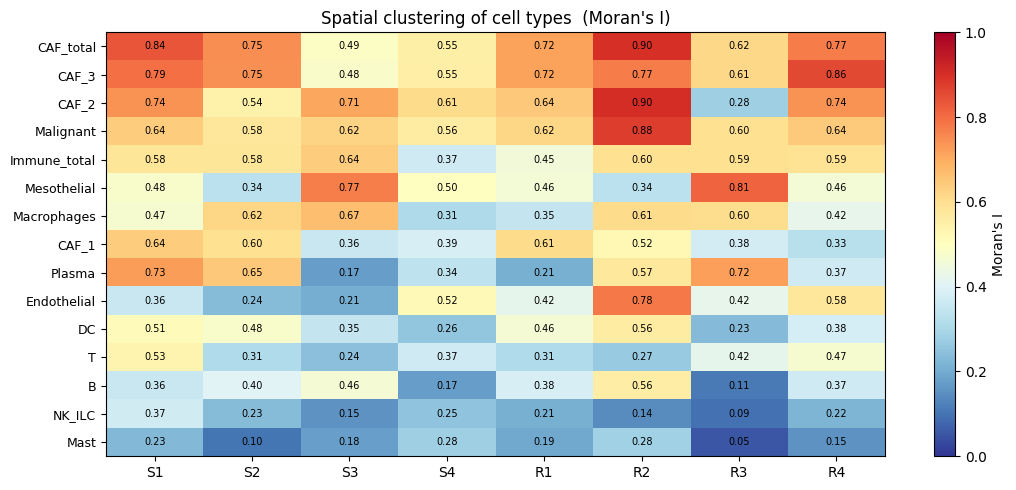


[saved] /content/drive/MyDrive/ovarian-spatial/metadata/morans_i_celltypes.csv


In [3]:

ORDER = ['S1','S2','S3','S4','R1','R2','R3','R4']
TYPES = list(adata.uns['prop_names'])
FEATS = TYPES + ['CAF_total', 'Immune_total']

def morans_i(values, W):
    """Global Moran's I for one feature on a binary neighbour matrix."""
    z = values - values.mean()
    denom = (z ** 2).sum()
    if denom == 0:
        return np.nan
    return (len(z) / W.sum()) * (z @ (W @ z)) / denom

def morans_i_perm(values, W, n_perm=199, seed=0):
    """Observed I plus a permutation-based pseudo p-value."""
    obs = morans_i(values, W)
    rng = np.random.default_rng(seed)
    null = np.array([morans_i(rng.permutation(values), W) for _ in range(n_perm)])
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    return obs, p, null.mean(), null.std()

W_all = adata.obsp['spatial_connectivities']
samp  = adata.obs.paper_id.to_numpy()

bar = '=' * 92
print(bar); print("MORAN'S I PER SAMPLE   (1 = fully clustered, 0 = random)"); print(bar)
print(f"{'feature':<14}", end='')
for sid in ORDER: print(f'{sid:>8}', end='')
print(f"{'mean':>8}")
print('-' * 92)

res = {}
for f in FEATS:
    vals = adata.obs[f].to_numpy(dtype=float)
    row = []
    for sid in ORDER:
        m = samp == sid
        Wi = W_all[m][:, m]
        row.append(morans_i(vals[m], Wi))
    res[f] = row
    print(f'{f:<14}', end='')
    for v in row: print(f'{v:>8.3f}', end='')
    print(f'{np.mean(row):>8.3f}')

moran = pd.DataFrame(res, index=ORDER).T
moran['mean'] = moran.mean(axis=1)
moran.to_csv(f'{META}/morans_i_celltypes.csv')

print('\n' + bar); print('SIGNIFICANCE CHECK  (199 permutations, sample R2)'); print(bar)
m = samp == 'R2'
Wi = W_all[m][:, m]
print(f"{'feature':<14}{'observed I':>12}{'null mean':>11}{'null sd':>9}{'p':>8}")
print('-' * 92)
for f in ['Malignant', 'CAF_total', 'Macrophages', 'Mast']:
    obs, p, nm, ns = morans_i_perm(adata.obs[f].to_numpy(dtype=float)[m], Wi)
    print(f'{f:<14}{obs:>12.3f}{nm:>11.3f}{ns:>9.3f}{p:>8.3f}')

print('\n' + bar); print('INTERPRETATION  (mean across samples)'); print(bar)
srt = moran['mean'].sort_values(ascending=False)
for f, v in srt.items():
    if   v > 0.6: tag = 'strongly clustered — forms distinct territories'
    elif v > 0.4: tag = 'clustered'
    elif v > 0.2: tag = 'weakly clustered'
    else:         tag = 'near random — dispersed through tissue'
    print(f'  {f:<14}{v:>7.3f}   {tag}')

print('\n' + bar); print('CLUSTERING BY GROUP'); print(bar)
print(f"{'feature':<14}{'resistant':>11}{'sensitive':>11}{'diff':>8}")
print('-' * 92)
for f in ['Malignant','CAF_total','CAF_2','CAF_3','Macrophages','Immune_total','T']:
    r  = moran.loc[f, ['R1','R2','R3','R4']].mean()
    s_ = moran.loc[f, ['S1','S2','S3','S4']].mean()
    print(f'{f:<14}{r:>11.3f}{s_:>11.3f}{r-s_:>8.3f}')

fig, ax = plt.subplots(figsize=(11, 5))
sub = moran.loc[srt.index, ORDER]
im = ax.imshow(sub.to_numpy(), cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(8)); ax.set_xticklabels(ORDER)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.index, fontsize=9)
for i in range(len(sub)):
    for j in range(8):
        ax.text(j, i, f'{sub.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, label="Moran's I")
ax.set_title("Spatial clustering of cell types  (Moran's I)")
fig.tight_layout()
fig.savefig(f'{FIG}/12_morans_i.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'\n[saved] {META}/morans_i_celltypes.csv')

CO-LOCALISATION Z-SCORE   (pooled, all samples)
positive = the two types sit next to each other more than expected

              Malignant     CAF_1     CAF_2     CAF_3 Macrophag         T    Plasma Endotheli
----------------------------------------------------------------------------------------------------
Malignant          43.8      15.3     -30.4     -34.1     -10.6     -22.5       2.1     -21.6
CAF_1              16.3      34.4     -17.0      -8.0      -6.5     -11.3       5.8     -14.4
CAF_2             -35.3     -18.0      51.2      22.0      -4.1      13.5      -1.5      26.4
CAF_3             -37.5      -8.0      21.7      51.0      -9.1       8.3      -0.6      21.7
Macrophages       -12.0      -5.4      -4.2      -8.4      37.2      13.6      -3.0      -8.4
T                 -24.7     -11.0      13.4       8.3      12.8      26.2      -2.1       8.3
Plasma              2.6       5.6      -1.9      -0.8      -4.3      -2.2      32.9      -0.8
Endothelial       -24.5     -14

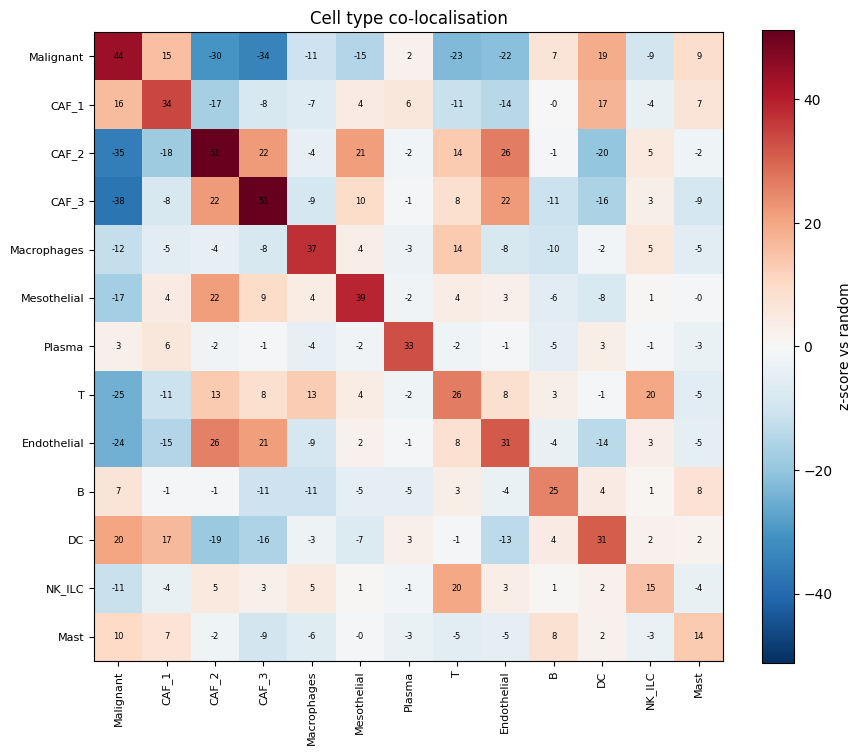


[saved] /content/drive/MyDrive/ovarian-spatial/metadata/colocalisation_zscores.csv


In [4]:

W = adata.obsp['spatial_connectivities']
P = adata.obsm['proportions']                 # spots x 13
TYPES = list(adata.uns['prop_names'])
samp = adata.obs.paper_id.to_numpy()
ORDER = ['S1','S2','S3','S4','R1','R2','R3','R4']

def colocalisation(P, W):
    """Mean composition of the neighbours of each cell type, per sample."""
    nb = W @ P                                 # summed neighbour composition
    deg = np.asarray(W.sum(1)).ravel()
    deg[deg == 0] = 1
    nb = nb / deg[:, None]                     # mean neighbour composition
    # weight each spot by how much of type i it contains
    num = P.T @ nb                             # 13 x 13
    den = P.sum(0)[:, None]
    return num / den                           # row i = neighbours of type i

def zscore_vs_null(P, W, n_perm=99, seed=0):
    obs = colocalisation(P, W)
    rng = np.random.default_rng(seed)
    null = np.stack([colocalisation(P[rng.permutation(len(P))], W)
                     for _ in range(n_perm)])
    return (obs - null.mean(0)) / (null.std(0) + 1e-12)

bar = '=' * 100
print(bar); print('CO-LOCALISATION Z-SCORE   (pooled, all samples)'); print(bar)
print('positive = the two types sit next to each other more than expected\n')

Z = np.zeros((len(TYPES), len(TYPES)))
for sid in ORDER:
    m = samp == sid
    Z += zscore_vs_null(P[m], W[m][:, m])
Z /= len(ORDER)
Zdf = pd.DataFrame(Z, index=TYPES, columns=TYPES)

SHOW = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Plasma','Endothelial']
print(f"{'':<13}", end='')
for c in SHOW: print(f'{c[:9]:>10}', end='')
print()
print('-' * 100)
for r in SHOW:
    print(f'{r:<13}', end='')
    for c in SHOW:
        v = Zdf.loc[r, c]
        print(f'{v:>10.1f}', end='')
    print()

Zdf.to_csv(f'{META}/colocalisation_zscores.csv')

print('\n' + bar); print('WHO NEIGHBOURS WHOM  (strongest partners)'); print(bar)
for t in ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Plasma']:
    s = Zdf.loc[t].drop(t).sort_values(ascending=False)
    print(f'\n{t}')
    print(f'   attracted to : {", ".join(f"{k} ({v:+.1f})" for k, v in s.head(3).items())}')
    print(f'   avoids       : {", ".join(f"{k} ({v:+.1f})" for k, v in s.tail(2).items())}')

print('\n' + bar); print('TUMOUR-CAF CONTACT BY GROUP'); print(bar)
print(f"{'ID':<5}{'grp':<5}{'Mal-CAF1':>11}{'Mal-CAF2':>11}{'Mal-CAF3':>11}"
      f"{'Mal-Macro':>12}{'Mal-T':>9}")
print('-' * 100)
rows = []
for sid in ORDER:
    m = samp == sid
    z = pd.DataFrame(zscore_vs_null(P[m], W[m][:, m]), index=TYPES, columns=TYPES)
    g = adata.obs.group[m].iloc[0][:1]
    print(f'{sid:<5}{g:<5}{z.loc["Malignant","CAF_1"]:>11.1f}'
          f'{z.loc["Malignant","CAF_2"]:>11.1f}{z.loc["Malignant","CAF_3"]:>11.1f}'
          f'{z.loc["Malignant","Macrophages"]:>12.1f}{z.loc["Malignant","T"]:>9.1f}')
    rows.append({'paper_id': sid, 'group': adata.obs.group[m].iloc[0],
                 'Mal_CAF1': z.loc['Malignant','CAF_1'],
                 'Mal_CAF2': z.loc['Malignant','CAF_2'],
                 'Mal_CAF3': z.loc['Malignant','CAF_3'],
                 'Mal_Macro': z.loc['Malignant','Macrophages'],
                 'Mal_T': z.loc['Malignant','T'],
                 'CAF3_Macro': z.loc['CAF_3','Macrophages']})
ct = pd.DataFrame(rows)
print('-' * 100)
print(f"{'mean R':<10}", end='')
for c in ['Mal_CAF1','Mal_CAF2','Mal_CAF3','Mal_Macro','Mal_T']:
    print(f'{ct.loc[ct.group=="resistant", c].mean():>11.1f}', end='')
print()
print(f"{'mean S':<10}", end='')
for c in ['Mal_CAF1','Mal_CAF2','Mal_CAF3','Mal_Macro','Mal_T']:
    print(f'{ct.loc[ct.group=="sensitive", c].mean():>11.1f}', end='')
print()
ct.to_csv(f'{META}/colocalisation_by_sample.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 7.5))
lim = np.abs(Zdf.values).max()
im = ax.imshow(Zdf.values, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_xticks(range(len(TYPES))); ax.set_xticklabels(TYPES, rotation=90, fontsize=8)
ax.set_yticks(range(len(TYPES))); ax.set_yticklabels(TYPES, fontsize=8)
for i in range(len(TYPES)):
    for j in range(len(TYPES)):
        ax.text(j, i, f'{Zdf.values[i,j]:.0f}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax, label='z-score vs random')
ax.set_title('Cell type co-localisation')
fig.tight_layout()
fig.savefig(f'{FIG}/13_colocalisation.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'\n[saved] {META}/colocalisation_zscores.csv')

In [6]:

!pip install -q igraph leidenalg 2>&1 | tail -2
import igraph, leidenalg
print('igraph   ', igraph.__version__)
print('leidenalg', leidenalg.version)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.0 MB/s eta 0:00:00
igraph    1.0.0
leidenalg 0.12.0


In [7]:

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

P     = adata.obsm['proportions']
TYPES = list(adata.uns['prop_names'])
W     = adata.obsp['spatial_connectivities']
samp  = adata.obs.paper_id.to_numpy()
ORDER = ['S1','S2','S3','S4','R1','R2','R3','R4']

# --- Banksy-style feature: own composition + neighbourhood composition ---
deg = np.asarray(W.sum(1)).ravel(); deg[deg == 0] = 1
NBR = (W @ P) / deg[:, None]
LAMBDA = 0.4                                   # weight of the spatial part
X_spatial = np.hstack([np.sqrt(1-LAMBDA) * P, np.sqrt(LAMBDA) * NBR])
X_plain   = P.copy()

adata.obsm['X_plain']   = X_plain
adata.obsm['X_spatial'] = X_spatial

bar = '=' * 92
print(bar); print('FEATURE SPACES'); print(bar)
print(f'plain   (own composition only)      : {X_plain.shape}')
print(f'spatial (own + neighbours, l={LAMBDA}) : {X_spatial.shape}')

def cluster(X, key, res=0.5):
    tmp = ad.AnnData(X=X.astype(np.float32))
    sc.pp.neighbors(tmp, n_neighbors=15, use_rep='X')
    sc.tl.leiden(tmp, resolution=res, key_added='l',
                 flavor='igraph', n_iterations=2, directed=False)
    adata.obs[key] = tmp.obs.l.to_numpy()
    adata.obs[key] = adata.obs[key].astype('category')
    return adata.obs[key]

print('\nclustering (plain) ...');   cluster(X_plain,   'clus_plain')
print('clustering (spatial) ...');   cluster(X_spatial, 'clus_spatial')

print('\n' + bar); print('CLUSTER COUNTS'); print(bar)
print(f'plain   : {adata.obs.clus_plain.nunique()} clusters')
print(f'spatial : {adata.obs.clus_spatial.nunique()} clusters')
print(f'\nARI between the two : {adjusted_rand_score(adata.obs.clus_plain, adata.obs.clus_spatial):.3f}')
print(f'NMI between the two : {normalized_mutual_info_score(adata.obs.clus_plain, adata.obs.clus_spatial):.3f}')

# --- how spatially coherent is each labelling? ---
def spatial_purity(labels):
    """fraction of a spot's neighbours carrying the same label"""
    lab = pd.Categorical(labels).codes
    same, tot = 0, 0
    src, dst = W.nonzero()
    same = (lab[src] == lab[dst]).sum()
    tot = len(src)
    return same / tot

print('\n' + bar); print('SPATIAL COHERENCE  (are neighbours in the same cluster?)'); print(bar)
for key in ['cluster', 'clus_plain', 'clus_spatial']:
    print(f'  {key:<14}{spatial_purity(adata.obs[key]):.3f}')
print('\n  cluster      = expression-based Leiden from 02 (space-blind)')
print('  clus_plain   = deconvolution composition, space-blind')
print('  clus_spatial = composition + neighbourhood')

print('\n' + bar); print('WHAT ARE THE SPATIAL CLUSTERS?'); print(bar)
comp = pd.DataFrame(P, columns=TYPES, index=adata.obs_names)
comp['k'] = adata.obs.clus_spatial.to_numpy()
prof = comp.groupby('k', observed=True)[TYPES].mean()
sizes = adata.obs.clus_spatial.value_counts()

SHOW = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Plasma','Endothelial']
print(f"{'k':<4}{'n':>7}{'%':>7}", end='')
for c in SHOW: print(f'{c[:9]:>10}', end='')
print('   dominant')
print('-' * 92)
for k in prof.index:
    print(f'{k:<4}{sizes[k]:>7}{100*sizes[k]/adata.n_obs:>6.1f}%', end='')
    for c in SHOW: print(f'{prof.loc[k, c]:>10.3f}', end='')
    print(f'   {prof.loc[k].idxmax()}')

print('\n' + bar); print('SPATIAL CLUSTER x GROUP  (% of each sample)'); print(bar)
tab = 100 * pd.crosstab(adata.obs.paper_id, adata.obs.clus_spatial, normalize='index')
print(tab.loc[ORDER].round(1).to_string())

print('\nmean per group:')
r = tab.loc[['R1','R2','R3','R4']].mean()
s_ = tab.loc[['S1','S2','S3','S4']].mean()
out = pd.DataFrame({'resistant': r, 'sensitive': s_,
                    'diff': r - s_, 'dominant': prof.idxmax(axis=1)})
print(out.round(2).to_string())

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_with_props.h5ad', compression='gzip')
print(f'\n[saved] clus_plain, clus_spatial in obs')

FEATURE SPACES
plain   (own composition only)      : (15312, 13)
spatial (own + neighbours, l=0.4) : (15312, 26)

clustering (plain) ...
clustering (spatial) ...

CLUSTER COUNTS
plain   : 14 clusters
spatial : 13 clusters

ARI between the two : 0.502
NMI between the two : 0.642

SPATIAL COHERENCE  (are neighbours in the same cluster?)
  cluster       0.670
  clus_plain    0.588
  clus_spatial  0.777

  cluster      = expression-based Leiden from 02 (space-blind)
  clus_plain   = deconvolution composition, space-blind
  clus_spatial = composition + neighbourhood

WHAT ARE THE SPATIAL CLUSTERS?
k         n      % Malignant     CAF_1     CAF_2     CAF_3 Macrophag         T    Plasma Endotheli   dominant
--------------------------------------------------------------------------------------------
0       848   5.5%     0.141     0.005     0.152     0.153     0.087     0.089     0.053     0.164   Endothelial
1      1364   8.9%     0.413     0.022     0.123     0.076     0.073     0.019     0